In [1]:
# ==========================================================
# CELL 1
# Install required libraries for Kaggle
# ==========================================================

print("Starting cell #1")

!pip install -q transformers scikit-learn pandas openpyxl seaborn

print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
# ==========================================================
# CELL 2
# Import all required Python libraries
# ==========================================================
print("Starting cell #2")

import os
import math
import random
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.optim import AdamW  # Added here (moved from transformers)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print("Executed cell #2")


Starting cell #2
Executed cell #2


In [3]:
# ==========================================================
# CELL 3
# Set random seeds for reproducibility
# ==========================================================

print("Starting cell #3")

SEED = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seed set to: {seed}")

set_seed(SEED)

print("Executed cell #3")

Starting cell #3
Seed set to: 42
Executed cell #3


In [4]:
# ==========================================================
# CELL 4
# Check whether GPU is available
# ==========================================================

print("Starting cell #4")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

print("Executed cell #4")

Starting cell #4
Using device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Executed cell #4


In [5]:
# ==========================================================
# CELL 5
# Load dataset splits from Kaggle input or working directory
# ==========================================================

print("Starting cell #5")

def find_file(filename):
    search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]
    for root in search_roots:
        matches = list(root.rglob(filename))
        if matches:
            return str(matches[0])
    raise FileNotFoundError(f"{filename} not found in /kaggle/input, /kaggle/working, or current directory.")

TRAIN_FILE = find_file("train.csv")
VAL_FILE   = find_file("validation.csv")
TEST_FILE  = find_file("test.csv")

print("Train file:", TRAIN_FILE)
print("Validation file:", VAL_FILE)
print("Test file:", TEST_FILE)

train_df = pd.read_csv(TRAIN_FILE)
val_df   = pd.read_csv(VAL_FILE)
test_df  = pd.read_csv(TEST_FILE)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

print("Executed cell #5")

Starting cell #5
Train file: /kaggle/input/datasets/sajedulislamsajid/dataset/train.csv
Validation file: /kaggle/input/datasets/sajedulislamsajid/dataset/validation.csv
Test file: /kaggle/input/datasets/sajedulislamsajid/dataset/test.csv
Train shape: (56067, 4)
Validation shape: (7929, 4)
Test shape: (16101, 4)


,Label,Bengali,Banglish,English
0,anger,মিন্নী যে জঘন্য কাজ করার পরও যদি জামিন পায়।তাহ...,minni je joghonjo kaj korar poro jodi jamin pa...,"If Minni gets bail despite the heinous act, th..."
1,joy,আলহামদুলিল্লাহ অবশেষে এখান থেকে বেরিয়ে এসে পা...,alhamdulillah obosheshe ekhan theke beriye esh...,Alhamdulillah he is finally able to get out of...
2,disgust,আপনার উচিত ছিল ওদের দিয়ে গাড়ি ঠিক করানো এরপর...,apnar ucit chil oder diye gari thik korano ero...,"You should have fixed the car with them, then ..."
3,disgust,মিন্নী কে মুক্তি দেওয়া হউক &#39; তার কারণ এই খ...,minni ke mukti deoya huk &#39; tar karon ei kh...,Let Minni be released &#39; The reason is that...
4,sadness,গানটা শুনলে কোনো 😢এক অচেনা শহরে হারিয়ে যায়😢 হয়...,ganta shunle kono 😢ek ocena shohore hariye jay...,Listening to the song makes one 😢 get lost in ...


Executed cell #5


In [6]:
# ==========================================================
# CELL 6
# Select label column and text columns
# ==========================================================

print("Starting cell #6")

LABEL_COLUMN = "Label"
TEXT_LANG_COLUMNS = ["Bengali", "Banglish", "English"]

print("Executed cell #6")

Starting cell #6
Executed cell #6


In [7]:
# ==========================================================
# CELL 7
# Convert emotion labels into numerical form
# ==========================================================

print("Starting cell #7")

label_encoder = LabelEncoder()

train_df[LABEL_COLUMN] = label_encoder.fit_transform(train_df[LABEL_COLUMN])
val_df[LABEL_COLUMN]   = label_encoder.transform(val_df[LABEL_COLUMN])
test_df[LABEL_COLUMN]  = label_encoder.transform(test_df[LABEL_COLUMN])

num_labels = len(label_encoder.classes_)

print("Emotion classes:", list(label_encoder.classes_))
print("Number of classes:", num_labels)

print("Executed cell #7")

Starting cell #7
Emotion classes: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
Number of classes: 6
Executed cell #7


Starting cell #8


/tmp/ipykernel_23/2028616646.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


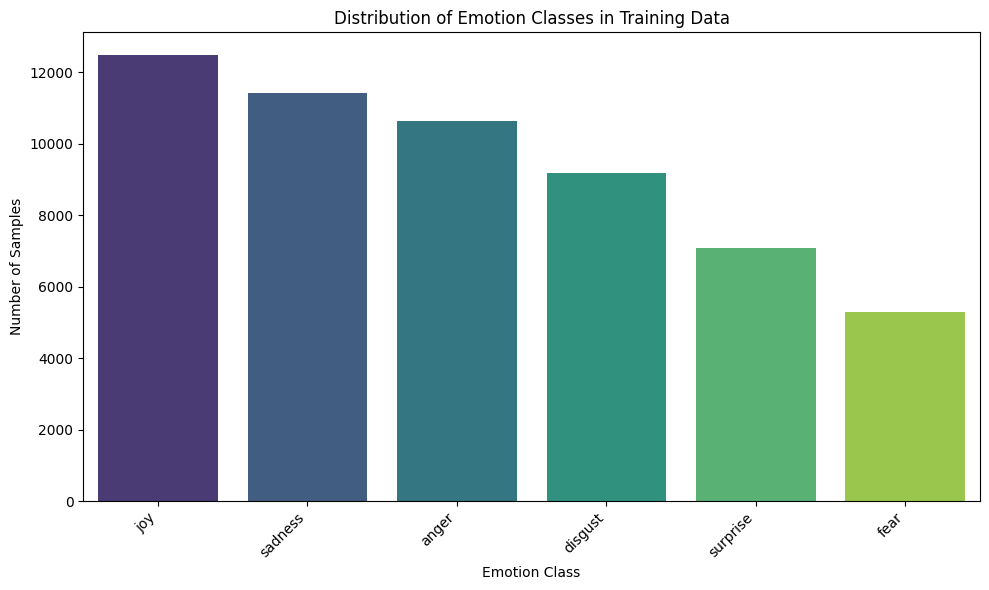

Emotion class distribution in training data:
joy         12486
sadness     11416
anger       10626
disgust      9169
surprise     7075
fear         5295
Name: count, dtype: int64
Executed cell #8


In [8]:
# ==========================================================
# CELL 8
# Visualize the distribution of emotion classes in the training data
# ==========================================================

print("Starting cell #8")

import matplotlib.pyplot as plt
import seaborn as sns

label_counts = train_df[LABEL_COLUMN].value_counts()

class_names = label_encoder.inverse_transform(label_counts.index)
label_counts.index = class_names

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Emotion Classes in Training Data')
plt.xlabel('Emotion Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Emotion class distribution in training data:")
print(label_counts)

print("Executed cell #8")

In [9]:
# ==========================================================
# CELL 9
# Compute class weights for imbalanced dataset
# ==========================================================

print("Starting cell #9")

class_counts_array = label_counts.sort_index().values
total_samples = train_df.shape[0]
num_classes = num_labels

raw_class_weights = np.sqrt(total_samples / (num_classes * class_counts_array))
class_weights = torch.tensor(raw_class_weights, dtype=torch.float)

print("Class counts (ordered):", dict(zip(label_encoder.classes_, class_counts_array)))
print("Raw class weights:", class_weights.tolist())

print("Executed cell #9")

Starting cell #9
Class counts (ordered): {'anger': np.int64(10626), 'disgust': np.int64(9169), 'fear': np.int64(5295), 'joy': np.int64(12486), 'sadness': np.int64(11416), 'surprise': np.int64(7075)}
Raw class weights: [0.9377630949020386, 1.009524941444397, 1.3284494876861572, 0.865100085735321, 0.9047343134880066, 1.1492507457733154]
Executed cell #9


In [10]:
# ==========================================================
# CELL 10
# Load tokenizer for multilingual transformer
# ==========================================================

print("Starting cell #10")

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Executed cell #10")

Starting cell #10


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Executed cell #10


In [11]:
# ==========================================================
# CELL 11
# Custom Dataset class for multilingual aligned emotion data
# Adds sample indices for instance-aware contrastive learning
# ==========================================================

print("Starting cell #11")

class EmotionDataset(Dataset):
    def __init__(self, dataframe, text_columns, label_column, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.text_columns = text_columns
        self.label_column = label_column
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        item = {}

        for col in self.text_columns:
            text = str(row[col])
            encoded = tokenizer(
                text,
                truncation=True,
                padding="max_length",
                max_length=self.max_length,
                return_tensors="pt"
            )

            item[f"{col}_input_ids"] = encoded["input_ids"].squeeze(0)
            item[f"{col}_attention_mask"] = encoded["attention_mask"].squeeze(0)

        item["labels"] = torch.tensor(int(row[self.label_column]), dtype=torch.long)
        item["sample_idx"] = torch.tensor(idx, dtype=torch.long)
        return item

print("Executed cell #11")

Starting cell #11
Executed cell #11


In [12]:
# ==========================================================
# CELL 12
# Create dataset objects for train, validation, and test
# ==========================================================

print("Starting cell #12")

train_dataset = EmotionDataset(train_df, TEXT_LANG_COLUMNS, LABEL_COLUMN, max_length=MAX_LENGTH)
val_dataset   = EmotionDataset(val_df, TEXT_LANG_COLUMNS, LABEL_COLUMN, max_length=MAX_LENGTH)
test_dataset  = EmotionDataset(test_df, TEXT_LANG_COLUMNS, LABEL_COLUMN, max_length=MAX_LENGTH)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

print("Executed cell #12")

Starting cell #12
Train dataset size: 56067
Validation dataset size: 7929
Test dataset size: 16101
Executed cell #12


In [13]:
# ==========================================================
# CELL 13
# Create DataLoaders
# Hybrid strategy:
# 1) Full-coverage shuffled loader for early epochs
# 2) Balanced batch loader for later epochs
# ==========================================================

print("Starting cell #13")

NUM_WORKERS = 2 if torch.cuda.is_available() else 0
PIN_MEMORY = torch.cuda.is_available()

CLASSES_PER_BATCH = min(num_labels, 8)
SAMPLES_PER_CLASS = 4
BALANCED_BATCH_SIZE = CLASSES_PER_BATCH * SAMPLES_PER_CLASS
EVAL_BATCH_SIZE = 32

# Early epochs prioritize full data coverage before stronger geometry shaping
FULL_COVERAGE_EPOCHS = 3

train_labels_list = train_df[LABEL_COLUMN].tolist()

class BalancedBatchSampler(Sampler):
    def __init__(self, labels, n_classes, n_samples, seed=42):
        self.labels = np.array(labels)
        self.labels_set = sorted(list(set(self.labels.tolist())))
        self.label_to_indices = defaultdict(list)

        for idx, label in enumerate(self.labels):
            self.label_to_indices[int(label)].append(idx)

        self.n_classes = n_classes
        self.n_samples = n_samples
        self.batch_size = self.n_classes * self.n_samples
        self.seed = seed
        self.dataset_length = len(self.labels)
        self.num_batches = max(1, self.dataset_length // self.batch_size)
        self.epoch = 0

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)

        for _ in range(self.num_batches):
            selected_classes = rng.choice(
                self.labels_set,
                size=self.n_classes,
                replace=(len(self.labels_set) < self.n_classes)
            )

            batch_indices = []
            for cls in selected_classes:
                cls_indices = self.label_to_indices[int(cls)]
                replace = len(cls_indices) < self.n_samples
                chosen = rng.choice(cls_indices, size=self.n_samples, replace=replace)
                batch_indices.extend(chosen.tolist())

            rng.shuffle(batch_indices)
            yield batch_indices

    def __len__(self):
        return self.num_batches

full_coverage_train_loader = DataLoader(
    train_dataset,
    batch_size=BALANCED_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

train_batch_sampler = BalancedBatchSampler(
    labels=train_labels_list,
    n_classes=CLASSES_PER_BATCH,
    n_samples=SAMPLES_PER_CLASS,
    seed=SEED
)

balanced_train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_batch_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0)
)

print("Full coverage epochs:", FULL_COVERAGE_EPOCHS)
print("Balanced batch size:", BALANCED_BATCH_SIZE)
print("Eval batch size:", EVAL_BATCH_SIZE)
print("Classes per balanced batch:", CLASSES_PER_BATCH)
print("Samples per class:", SAMPLES_PER_CLASS)
print("Full coverage train batches:", len(full_coverage_train_loader))
print("Balanced train batches:", len(balanced_train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("Executed cell #13")

Starting cell #13
Full coverage epochs: 3
Balanced batch size: 24
Eval batch size: 32
Classes per balanced batch: 6
Samples per class: 4
Full coverage train batches: 2337
Balanced train batches: 2336
Validation batches: 248
Test batches: 504
Executed cell #13


In [14]:
# ==========================================================
# CELL 14
# Stronger multilingual emotion model
# Shared encoder + attentive pooling + gated interaction fusion
# ==========================================================

print("Starting cell #14")

class AttentionPooling(nn.Module):
    def __init__(self, hidden_size, dropout=0.1):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, hidden_states, attention_mask):
        scores = self.score(hidden_states).squeeze(-1)

        # AMP-safe mask fill
        mask_value = torch.finfo(scores.dtype).min
        scores = scores.masked_fill(attention_mask == 0, mask_value)

        attn = torch.softmax(scores, dim=-1)
        pooled = torch.sum(hidden_states * attn.unsqueeze(-1), dim=1)
        return pooled


class MultilingualEmotionModel(nn.Module):
    def __init__(
        self,
        num_labels,
        model_name="xlm-roberta-base",
        projection_dim=256,
        dropout=0.3,
        inference_blend_alpha=0.20
    ):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.hidden_size = hidden_size
        self.repr_dim = hidden_size * 3
        self.inference_blend_alpha = inference_blend_alpha

        self.attn_pool = AttentionPooling(hidden_size, dropout=dropout)
        self.view_norm = nn.LayerNorm(self.repr_dim)

        self.projection_head = nn.Sequential(
            nn.Linear(self.repr_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, projection_dim)
        )

        self.view_classifier = nn.Sequential(
            nn.LayerNorm(self.repr_dim),
            nn.Dropout(dropout),
            nn.Linear(self.repr_dim, num_labels)
        )

        self.fusion_gate = nn.Sequential(
            nn.Linear(self.repr_dim * 3, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 3)
        )

        self.fusion_mlp = nn.Sequential(
            nn.Linear(self.repr_dim * 3, hidden_size * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, self.repr_dim),
            nn.LayerNorm(self.repr_dim)
        )

        self.fused_classifier = nn.Sequential(
            nn.LayerNorm(self.repr_dim),
            nn.Dropout(dropout),
            nn.Linear(self.repr_dim, num_labels)
        )

    def masked_mean_pool(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        summed = torch.sum(last_hidden_state * mask, dim=1)
        counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        return summed / counts

    def masked_max_pool(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).bool()
        masked_hidden = last_hidden_state.masked_fill(~mask, torch.finfo(last_hidden_state.dtype).min)
        return torch.max(masked_hidden, dim=1).values

    def encode_text(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state

        mean_pooled = self.masked_mean_pool(last_hidden, attention_mask)
        max_pooled = self.masked_max_pool(last_hidden, attention_mask)
        attn_pooled = self.attn_pool(last_hidden, attention_mask)

        view_repr = torch.cat([mean_pooled, max_pooled, attn_pooled], dim=-1)
        view_repr = self.view_norm(view_repr)
        view_proj = F.normalize(self.projection_head(view_repr), dim=-1)
        view_logits = self.view_classifier(view_repr)

        return view_repr, view_proj, view_logits

    def forward(
        self,
        input_ids_bengali,
        attention_mask_bengali,
        input_ids_banglish,
        attention_mask_banglish,
        input_ids_english,
        attention_mask_english
    ):
        bn_repr, bn_proj, bn_logits = self.encode_text(input_ids_bengali, attention_mask_bengali)
        bl_repr, bl_proj, bl_logits = self.encode_text(input_ids_banglish, attention_mask_banglish)
        en_repr, en_proj, en_logits = self.encode_text(input_ids_english, attention_mask_english)

        stacked_repr = torch.stack([bn_repr, bl_repr, en_repr], dim=1)
        concat_repr = torch.cat([bn_repr, bl_repr, en_repr], dim=-1)

        gate_logits = self.fusion_gate(concat_repr)
        gate_weights = torch.softmax(gate_logits, dim=-1)

        gated_views = stacked_repr * gate_weights.unsqueeze(-1)
        fusion_input = torch.cat(
            [gated_views[:, 0, :], gated_views[:, 1, :], gated_views[:, 2, :]],
            dim=-1
        )

        fused_repr = self.fusion_mlp(fusion_input)
        fused_logits = self.fused_classifier(fused_repr)

        avg_view_logits = (bn_logits + bl_logits + en_logits) / 3.0
        main_logits = (1.0 - self.inference_blend_alpha) * fused_logits + self.inference_blend_alpha * avg_view_logits

        return {
            "logits": main_logits,
            "main_logits": main_logits,
            "fused_logits": fused_logits,
            "avg_view_logits": avg_view_logits,
            "view_logits": [bn_logits, bl_logits, en_logits],
            "projected_views": [bn_proj, bl_proj, en_proj],
            "view_representations": [bn_repr, bl_repr, en_repr],
            "fused_representation": fused_repr,
            "gate_weights": gate_weights
        }

model = MultilingualEmotionModel(
    num_labels=num_labels,
    model_name=MODEL_NAME
)

if torch.cuda.device_count() > 1:
    print(f"Using DataParallel on {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

print("Executed cell #14")

Starting cell #14


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using DataParallel on 2 GPUs
Executed cell #14


In [15]:
# ==========================================================
# CELL 15
# Check CUDA setup
# ==========================================================

print("Starting cell #15")

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

print("Executed cell #15")

Starting cell #15
CUDA available: True
CUDA device count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Executed cell #15


In [16]:
# ==========================================================
# CELL 16
# Optimizer, losses, AMP scaler, and scheduler
# Layer-wise learning rates + label smoothing
# ==========================================================

print("Starting cell #16")

EPOCHS = 10
WARMUP_EPOCHS = 1
BASE_ENCODER_LR = 1e-5
HEAD_LR = 6e-5
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
BEST_MODEL_MONITOR = "macro_f1"

model_for_opt = model.module if isinstance(model, nn.DataParallel) else model

encoder_params = list(model_for_opt.encoder.named_parameters())

lower_encoder_params = []
upper_encoder_params = []

for name, param in encoder_params:
    if any(layer_name in name for layer_name in ["layer.8", "layer.9", "layer.10", "layer.11"]):
        upper_encoder_params.append(param)
    else:
        lower_encoder_params.append(param)

head_params = []
for name, param in model_for_opt.named_parameters():
    if not name.startswith("encoder."):
        head_params.append(param)

optimizer = AdamW(
    [
        {"params": lower_encoder_params, "lr": BASE_ENCODER_LR * 0.65},
        {"params": upper_encoder_params, "lr": BASE_ENCODER_LR},
        {"params": head_params, "lr": HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=0.05
)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

if WARMUP_EPOCHS > EPOCHS:
    raise ValueError("WARMUP_EPOCHS cannot be greater than EPOCHS")

num_full_epochs = FULL_COVERAGE_EPOCHS
num_balanced_epochs = EPOCHS - FULL_COVERAGE_EPOCHS

total_training_steps = (
    len(full_coverage_train_loader) * num_full_epochs
    + len(balanced_train_loader) * num_balanced_epochs
)

warmup_steps = max(1, int(0.10 * total_training_steps))

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print("EPOCHS:", EPOCHS)
print("WARMUP_EPOCHS:", WARMUP_EPOCHS)
print("FULL_COVERAGE_EPOCHS:", FULL_COVERAGE_EPOCHS)
print("Balanced epochs:", num_balanced_epochs)
print("Full coverage loader batches:", len(full_coverage_train_loader))
print("Balanced loader batches:", len(balanced_train_loader))
print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)

print("Executed cell #16")

Starting cell #16
EPOCHS: 10
WARMUP_EPOCHS: 1
FULL_COVERAGE_EPOCHS: 3
Balanced epochs: 7
Full coverage loader batches: 2337
Balanced loader batches: 2336
Total training steps: 23363
Warmup steps: 2336
Executed cell #16


In [17]:
# ==========================================================
# CELL 17
# Define stronger contrastive and consistency losses
# ==========================================================

print("Starting cell #17")

class WeightedMultiViewSupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07, same_instance_weight=1.0, same_label_weight=0.35):
        super().__init__()
        self.temperature = temperature
        self.same_instance_weight = same_instance_weight
        self.same_label_weight = same_label_weight

    def forward(self, projected_views, labels, sample_indices):
        device_local = projected_views[0].device
        num_views = len(projected_views)
        batch_size = projected_views[0].size(0)

        features = torch.cat(projected_views, dim=0)
        features = F.normalize(features, dim=1)

        labels = labels.view(-1, 1)
        repeated_labels = labels.repeat(num_views, 1)

        sample_indices = sample_indices.view(-1, 1)
        repeated_indices = sample_indices.repeat(num_views, 1)

        label_mask = torch.eq(repeated_labels, repeated_labels.T).float().to(device_local)
        instance_mask = torch.eq(repeated_indices, repeated_indices.T).float().to(device_local)

        logits = torch.matmul(features, features.T) / self.temperature
        logits_max, _ = torch.max(logits, dim=1, keepdim=True)
        logits = logits - logits_max.detach()

        logits_mask = torch.ones_like(logits, device=device_local) - torch.eye(num_views * batch_size, device=device_local)

        weighted_positive_mask = (
            self.same_label_weight * label_mask +
            (self.same_instance_weight - self.same_label_weight) * instance_mask
        ) * logits_mask

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

        positive_weight_sum = weighted_positive_mask.sum(dim=1)
        mean_log_prob_pos = (weighted_positive_mask * log_prob).sum(dim=1) / torch.clamp(positive_weight_sum, min=1e-12)

        valid_rows = positive_weight_sum > 0
        if valid_rows.any():
            loss = -mean_log_prob_pos[valid_rows].mean()
        else:
            loss = torch.tensor(0.0, device=device_local)

        return loss


class MultiViewConsistencyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.kl = nn.KLDivLoss(reduction="batchmean")

    def forward(self, fused_logits, view_logits):
        fused_prob = torch.softmax(fused_logits.detach(), dim=-1)
        total_loss = 0.0
        for logits in view_logits:
            total_loss = total_loss + self.kl(
                torch.log_softmax(logits, dim=-1),
                fused_prob
            )
        return total_loss / len(view_logits)


supcon_criterion = WeightedMultiViewSupervisedContrastiveLoss(
    temperature=0.07,
    same_instance_weight=1.0,
    same_label_weight=0.35
)
consistency_criterion = MultiViewConsistencyLoss()

print("Executed cell #17")

Starting cell #17
Executed cell #17


In [18]:
# ==========================================================
# CELL 18
# Train model for one epoch
# Hybrid strategy with 2-line live tqdm display
# Line 1: progress bar
# Line 2: live loss/status line (updates in place)
# ==========================================================

print("Starting cell #18")

def gate_entropy_regularizer(gate_weights):
    entropy = -(gate_weights * torch.log(gate_weights + 1e-12)).sum(dim=1).mean()
    max_entropy = math.log(gate_weights.size(1))
    return -entropy / max_entropy


def train_epoch(epoch_num):
    model.train()

    total_loss = 0.0
    total_main_ce = 0.0
    total_view_ce = 0.0
    total_supcon = 0.0
    total_consistency = 0.0
    total_gate_reg = 0.0

    if epoch_num <= FULL_COVERAGE_EPOCHS:
        current_train_loader = full_coverage_train_loader
        stage_name = "full_coverage"
        lambda_view_ce = 0.25
        lambda_supcon = 0.02
        lambda_consistency = 0.02
        lambda_gate_reg = 0.01
    else:
        train_batch_sampler.set_epoch(epoch_num)
        current_train_loader = balanced_train_loader
        stage_name = "balanced_batches"
        lambda_view_ce = 0.25
        lambda_supcon = 0.06
        lambda_consistency = 0.05
        lambda_gate_reg = 0.00

    # Main progress bar (line 1)
    progress_bar = tqdm(
        current_train_loader,
        desc=f"Training Epoch {epoch_num} [{stage_name}]",
        position=0,
        leave=True
    )

    # Live status line (line 2)
    status_bar = tqdm(
        total=0,
        bar_format="{desc}",
        position=1,
        leave=True
    )

    for step, batch in enumerate(progress_bar, start=1):
        optimizer.zero_grad(set_to_none=True)

        labels = batch["labels"].to(device, non_blocking=True)
        sample_indices = batch["sample_idx"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            outputs = model(
                input_ids_bengali=batch["Bengali_input_ids"].to(device, non_blocking=True),
                attention_mask_bengali=batch["Bengali_attention_mask"].to(device, non_blocking=True),
                input_ids_banglish=batch["Banglish_input_ids"].to(device, non_blocking=True),
                attention_mask_banglish=batch["Banglish_attention_mask"].to(device, non_blocking=True),
                input_ids_english=batch["English_input_ids"].to(device, non_blocking=True),
                attention_mask_english=batch["English_attention_mask"].to(device, non_blocking=True)
            )

            main_logits = outputs["main_logits"]
            fused_logits = outputs["fused_logits"]
            view_logits = outputs["view_logits"]
            projected_views = outputs["projected_views"]
            gate_weights = outputs["gate_weights"]

            main_ce_loss = criterion(main_logits, labels)
            view_ce_loss = sum(criterion(v_logits, labels) for v_logits in view_logits) / len(view_logits)
            supcon_loss = supcon_criterion(projected_views, labels, sample_indices)
            consistency_loss = consistency_criterion(fused_logits, view_logits)
            gate_reg_loss = gate_entropy_regularizer(gate_weights)

            loss = (
                main_ce_loss
                + lambda_view_ce * view_ce_loss
                + lambda_supcon * supcon_loss
                + lambda_consistency * consistency_loss
                + lambda_gate_reg * gate_reg_loss
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        scale_after = scaler.get_scale()

        if scale_after >= scale_before:
            scheduler.step()

        total_loss += loss.item()
        total_main_ce += main_ce_loss.item()
        total_view_ce += view_ce_loss.item()
        total_supcon += supcon_loss.item()
        total_consistency += consistency_loss.item()
        total_gate_reg += gate_reg_loss.item()

        current_lr = optimizer.param_groups[-1]["lr"]

        avg_loss_so_far = total_loss / step
        avg_main_ce_so_far = total_main_ce / step
        avg_view_ce_so_far = total_view_ce / step
        avg_supcon_so_far = total_supcon / step
        avg_consistency_so_far = total_consistency / step

        # Keep first line clean
        progress_bar.set_postfix({
            "loss": f"{avg_loss_so_far:.4f}",
            "lr": f"{current_lr:.2e}"
        })

        # Update second line in place
        status_bar.set_description_str(
            f"main_ce={avg_main_ce_so_far:.4f} | "
            f"view_ce={avg_view_ce_so_far:.4f} | "
            f"supcon={avg_supcon_so_far:.4f} | "
            f"cons={avg_consistency_so_far:.4f}"
        )

    status_bar.close()

    avg_loss = total_loss / len(current_train_loader)
    avg_main_ce = total_main_ce / len(current_train_loader)
    avg_view_ce = total_view_ce / len(current_train_loader)
    avg_supcon = total_supcon / len(current_train_loader)
    avg_consistency = total_consistency / len(current_train_loader)
    avg_gate_reg = total_gate_reg / len(current_train_loader)

    return avg_loss, avg_main_ce, avg_view_ce, avg_supcon, avg_consistency, avg_gate_reg, stage_name

print("Executed cell #18")

Starting cell #18
Executed cell #18


In [19]:
# ==========================================================
# CELL 19
# Evaluate model performance using blended prediction
# ==========================================================

print("Starting cell #19")

def evaluate(loader):
    model.eval()

    preds = []
    labels = []

    with torch.no_grad():
        for batch in loader:
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                outputs = model(
                    input_ids_bengali=batch["Bengali_input_ids"].to(device, non_blocking=True),
                    attention_mask_bengali=batch["Bengali_attention_mask"].to(device, non_blocking=True),
                    input_ids_banglish=batch["Banglish_input_ids"].to(device, non_blocking=True),
                    attention_mask_banglish=batch["Banglish_attention_mask"].to(device, non_blocking=True),
                    input_ids_english=batch["English_input_ids"].to(device, non_blocking=True),
                    attention_mask_english=batch["English_attention_mask"].to(device, non_blocking=True)
                )

                logits = outputs["main_logits"]

            predictions = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(predictions)
            labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(labels, preds)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    return acc, precision, recall, f1_macro, f1_weighted

print("Executed cell #19")

Starting cell #19
Executed cell #19


In [20]:
# ==========================================================
# CELL 20
# Kaggle working directory setup
# ==========================================================

print("Starting cell #20")

WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)

print("Kaggle working directory:", WORK_DIR)
print("Files saved here will appear in the notebook output section.")

print("Executed cell #20")

Starting cell #20
Kaggle working directory: /kaggle/working
Files saved here will appear in the notebook output section.
Executed cell #20


In [21]:
# ==========================================================
# CELL 21
# Define training loop and save best model checkpoints locally in Kaggle
# ==========================================================

print("Starting cell #21")

checkpoint_save_dir = "/kaggle/working/emotion_model_checkpoints"
os.makedirs(checkpoint_save_dir, exist_ok=True)

MODEL_CHECKPOINT_NAME = "best_language_invariant_model.pt"
checkpoint_path = os.path.join(checkpoint_save_dir, MODEL_CHECKPOINT_NAME)

best_val_f1 = 0.0
best_checkpoint_epoch = -1
history = []

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch + 1}/{EPOCHS} =====")

    train_loss, main_ce, view_ce, supcon, consistency, gate_reg, stage_name = train_epoch(epoch + 1)
    print(f"Training stage: {stage_name}")
    val_acc, val_prec, val_rec, val_f1_macro, val_f1_weighted = evaluate(val_loader)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "main_ce": main_ce,
        "view_ce": view_ce,
        "supcon": supcon,
        "consistency": consistency,
        "gate_reg": gate_reg,
        "val_acc": val_acc,
        "val_prec": val_prec,
        "val_rec": val_rec,
        "val_f1_macro": val_f1_macro,
        "val_f1_weighted": val_f1_weighted
    })

    print(f"Train Loss: {train_loss:.4f}")
    print(f"  Main CE Loss: {main_ce:.4f}")
    print(f"  View CE Loss: {view_ce:.4f}")
    print(f"  SupCon Loss: {supcon:.4f}")
    print(f"  Consistency Loss: {consistency:.4f}")
    print(f"  Gate Reg Loss: {gate_reg:.4f}")

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Validation Precision: {val_prec:.4f}")
    print(f"Validation Recall: {val_rec:.4f}")
    print(f"Validation Macro F1: {val_f1_macro:.4f}")
    print(f"Validation Weighted F1: {val_f1_weighted:.4f}")

    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        best_checkpoint_epoch = epoch + 1

        model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_f1": best_val_f1,
            "label_classes": list(label_encoder.classes_),
            "model_name": MODEL_NAME,
            "max_length": MAX_LENGTH,
            "strategy": {
                "pooling": "mean_max_attention",
                "fusion": "gated_interaction_mlp",
                "prediction": "0.8_fused_plus_0.2_avg_view",
                "supcon": "weighted_same_instance_plus_same_label",
                "consistency": "view_to_fused_kl"
            }
        }

        torch.save(checkpoint, checkpoint_path)
        print(f"Best model updated and saved to: {checkpoint_path}")

history_df = pd.DataFrame(history)
display(history_df)

print(f"\nTraining complete. Best validation Macro F1: {best_val_f1:.4f}")
print(f"Best checkpoint epoch: {best_checkpoint_epoch}")
print(f"Final checkpoint path: {checkpoint_path}")

print("Executed cell #21")

Starting cell #21

===== Epoch 1/10 =====


Training Epoch 1 [full_coverage]:   0%|          | 0/2337 [00:00<?, ?it/s]

Training stage: full_coverage
Train Loss: 1.8572
  Main CE Loss: 1.3750
  View CE Loss: 1.6017
  SupCon Loss: 4.0797
  Consistency Loss: 0.4140
  Gate Reg Loss: -0.8027
Validation Accuracy: 0.5595
Validation Precision: 0.6038
Validation Recall: 0.5675
Validation Macro F1: 0.5439
Validation Weighted F1: 0.5492
Best model updated and saved to: /kaggle/working/emotion_model_checkpoints/best_language_invariant_model.pt

===== Epoch 2/10 =====


Training Epoch 2 [full_coverage]:   0%|          | 0/2337 [00:00<?, ?it/s]

Training stage: full_coverage
Train Loss: 1.5096
  Main CE Loss: 1.1200
  View CE Loss: 1.2703
  SupCon Loss: 3.7575
  Consistency Loss: 0.2423
  Gate Reg Loss: -0.7953
Validation Accuracy: 0.6302
Validation Precision: 0.6465
Validation Recall: 0.6199
Validation Macro F1: 0.6282
Validation Weighted F1: 0.6273
Best model updated and saved to: /kaggle/working/emotion_model_checkpoints/best_language_invariant_model.pt

===== Epoch 3/10 =====


...

Training stage: balanced_batches
Train Loss: 1.0516
  Main CE Loss: 0.6005
  View CE Loss: 0.9251
  SupCon Loss: 3.3461
  Consistency Loss: 0.3809
  Gate Reg Loss: -0.7475
Validation Accuracy: 0.6556
Validation Precision: 0.6503
Validation Recall: 0.6587
Validation Macro F1: 0.6537
Validation Weighted F1: 0.6546

===== Epoch 10/10 =====


Training Epoch 10 [balanced_batches]:   0%|          | 0/2336 [00:00<?, ?it/s]

Training stage: balanced_batches
Train Loss: 1.0216
  Main CE Loss: 0.5730
  View CE Loss: 0.9147
  SupCon Loss: 3.3336
  Consistency Loss: 0.3977
  Gate Reg Loss: -0.7489
Validation Accuracy: 0.6533
Validation Precision: 0.6464
Validation Recall: 0.6566
Validation Macro F1: 0.6505
Validation Weighted F1: 0.6518


,epoch,train_loss,main_ce,view_ce,supcon,consistency,gate_reg,val_acc,val_prec,val_rec,val_f1_macro,val_f1_weighted
0,1,1.857250,1.374978,1.601700,4.079697,0.414001,-0.802667,0.559465,0.603823,0.567458,0.543862,0.549198
1,2,1.509623,1.120011,1.270278,3.757533,0.242283,-0.795323,0.630218,0.646461,0.619863,0.628175,0.627288
2,3,1.374694,1.011149,1.176114,3.660706,0.228963,-0.827739,0.644722,0.660171,0.643318,0.644075,0.643153
3,4,1.350452,0.858967,1.070774,3.508623,0.265481,-0.779921,0.622651,0.613013,0.637239,0.615604,0.621789
4,5,1.265147,0.786950,1.024858,3.456602,0.291721,-0.747299,0.652667,0.642434,0.659027,0.648766,0.651295
5,6,1.188024,0.721173,0.984990,3.412392,0.317183,-0.737759,0.647118,0.634981,0.655117,0.641067,0.644729
6,7,1.126839,0.667527,0.956584,3.383534,0.343071,-0.734390,0.653298,0.646228,0.659359,0.650796,0.652002
7,8,1.088079,0.633695,0.938430,3.362480,0.360570,-0.739347,0.656325,0.651932,0.658328,0.654659,0.655368
8,9,1.051552,0.600465,0.925106,3.346066,0.380929,-0.747534,0.655568,0.650342,0.658738,0.653671,0.654604
9,10,1.021617,0.573031,0.914747,3.333595,0.397680,-0.748945,0.653298,0.646364,0.656596,0.650522,0.651810



Training complete. Best validation Macro F1: 0.6547
Best checkpoint epoch: 8
Final checkpoint path: /kaggle/working/emotion_model_checkpoints/best_language_invariant_model.pt
Executed cell #21


In [22]:
# ==========================================================
# CELL 22
# Evaluate model on the test dataset
# ==========================================================

print("Starting cell #22")

if os.path.exists(checkpoint_path):
    print(f"Loading best model from checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    print(f"Checkpoint epoch: {checkpoint['epoch']}")
    print(f"Best validation F1 from checkpoint: {checkpoint['best_val_f1']:.4f}")
    if "strategy" in checkpoint:
        print("Saved strategy:", checkpoint["strategy"])
else:
    print("Checkpoint not found. Evaluating current in-memory model.")

test_acc, test_prec, test_rec, test_f1_macro, test_f1_weighted = evaluate(test_loader)

print("\n===== Test Set Performance =====")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print(f"Test Macro F1: {test_f1_macro:.4f}")
print(f"Test Weighted F1: {test_f1_weighted:.4f}")

print("Executed cell #22")

Starting cell #22
Loading best model from checkpoint: /kaggle/working/emotion_model_checkpoints/best_language_invariant_model.pt
Checkpoint epoch: 8
Best validation F1 from checkpoint: 0.6547
Saved strategy: {'pooling': 'mean_max_attention', 'fusion': 'gated_interaction_mlp', 'prediction': '0.8_fused_plus_0.2_avg_view', 'supcon': 'weighted_same_instance_plus_same_label', 'consistency': 'view_to_fused_kl'}

===== Test Set Performance =====
Test Accuracy: 0.6597
Test Precision: 0.6577
Test Recall: 0.6603
Test Macro F1: 0.6586
Test Weighted F1: 0.6597
Executed cell #22


In [23]:
# ==========================================================
# CELL 23
# Generate and display confusion matrix for test predictions
# ==========================================================

print("Starting cell #23")

def plot_confusion_matrix(loader):
    model.eval()

    pred_labels = []
    true_labels = []

    with torch.no_grad():
        for batch in loader:
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                outputs = model(
                    input_ids_bengali=batch["Bengali_input_ids"].to(device, non_blocking=True),
                    attention_mask_bengali=batch["Bengali_attention_mask"].to(device, non_blocking=True),
                    input_ids_banglish=batch["Banglish_input_ids"].to(device, non_blocking=True),
                    attention_mask_banglish=batch["Banglish_attention_mask"].to(device, non_blocking=True),
                    input_ids_english=batch["English_input_ids"].to(device, non_blocking=True),
                    attention_mask_english=batch["English_attention_mask"].to(device, non_blocking=True)
                )

                preds = torch.argmax(outputs["main_logits"], dim=1)

            pred_labels.extend(preds.cpu().numpy())
            true_labels.extend(batch["labels"].cpu().numpy())

    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix on Test Set")
    plt.tight_layout()
    plt.show()

print("Executed cell #23")

Starting cell #23
Executed cell #23


Starting cell #24


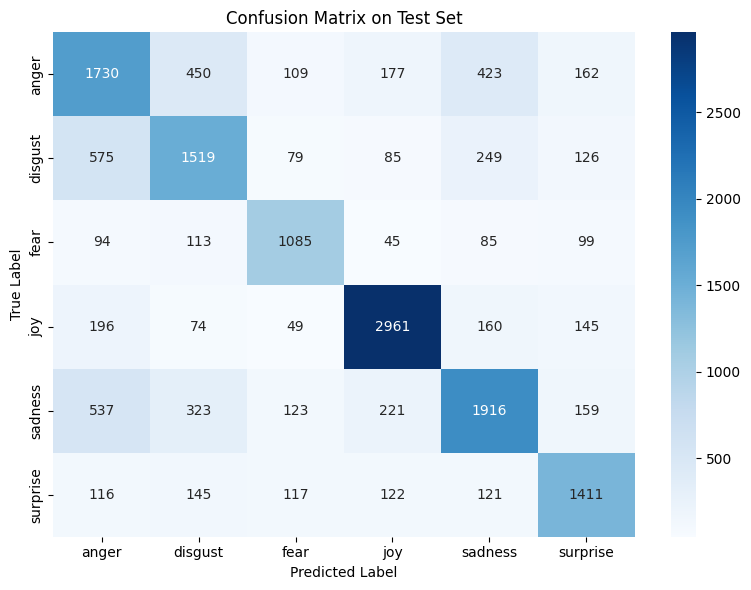

Executed cell #24


In [24]:
# ==========================================================
# CELL 24
# Call function to visualize confusion matrix
# ==========================================================

print("Starting cell #24")

plot_confusion_matrix(test_loader)

print("Executed cell #24")